<a href="https://colab.research.google.com/github/redrosesarecool/staz/blob/main/regresja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Przykład

Generating 100 samples and fitting 10-degree polynomials...


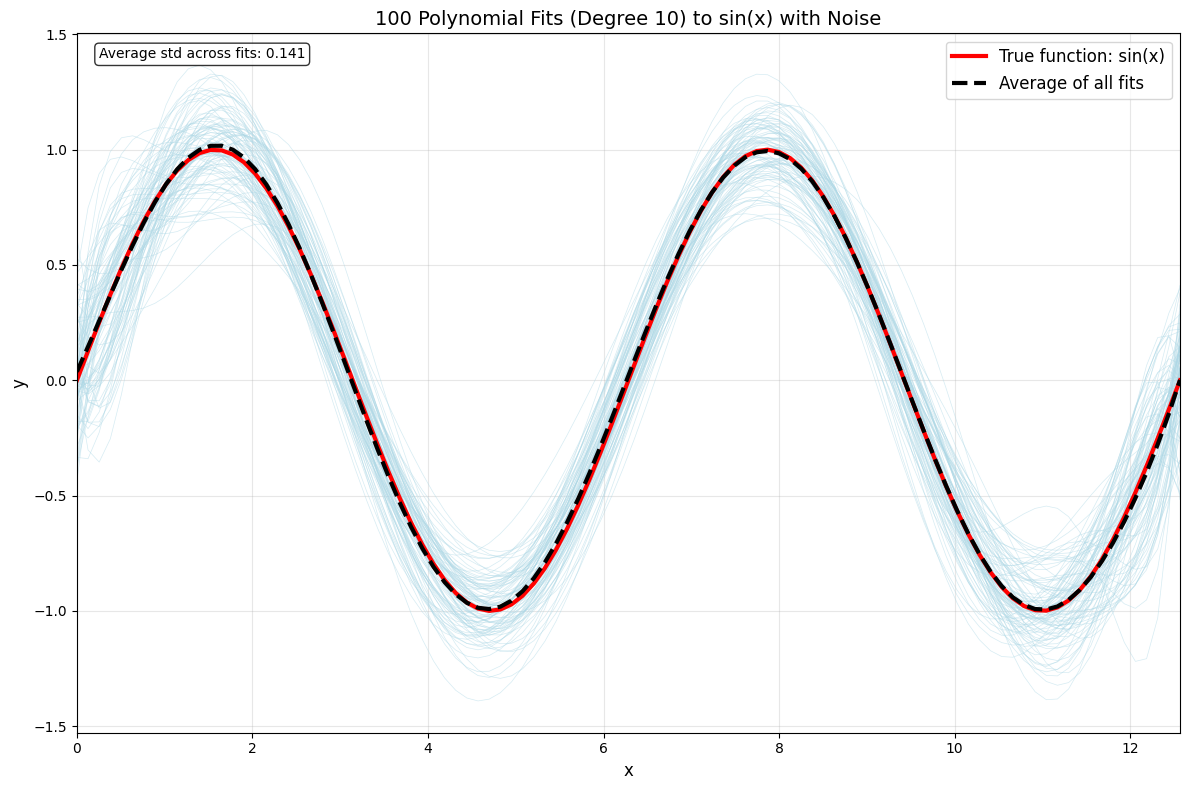


Statistics:
Number of samples: 100
Events per sample: 20
Polynomial degree: 10
Average standard deviation of fits: 0.1414


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Set random seed for reproducibility
np.random.seed(43)

# Parameters
n_samples = 100
n_events = 20
degree = 10
x_range = (0, 4*np.pi)

# Generate base x values
x_base = np.linspace(x_range[0], x_range[1], n_events)

# Store all fits and predictions
all_fits = []
x_plot = np.linspace(x_range[0], x_range[1], 100)  # Smooth x for plotting

# Create figure
plt.figure(figsize=(12, 8))

print(f"Generating {n_samples} samples and fitting {degree}-degree polynomials...")

for i in range(n_samples):
    # Generate sample with noise
    noise = np.random.normal(0, 0.2, n_events)  # Add some noise
    y_sample = np.sin(x_base) + noise

    # Create polynomial regression model
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    # Fit the model
    model.fit(x_base.reshape(-1, 1), y_sample)

    # Predict on smooth x range for plotting
    y_fit = model.predict(x_plot.reshape(-1, 1))
    all_fits.append(y_fit)

    # Plot individual fit with low alpha
    plt.plot(x_plot, y_fit, 'lightblue', alpha=0.5, linewidth=0.5)

# Calculate average fit
average_fit = np.mean(all_fits, axis=0)

# Plot true function
true_function = np.sin(x_plot)
plt.plot(x_plot, true_function, 'red', linewidth=3, label='True function: sin(x)')

# Plot average fit
plt.plot(x_plot, average_fit, 'black', linewidth=3, linestyle='--', label='Average of all fits')

# Formatting
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'100 Polynomial Fits (Degree {degree}) to sin(x) with Noise', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(x_range)

# Add text box with statistics
fit_std = np.std(all_fits, axis=0)
avg_std = np.mean(fit_std)
plt.text(0.02, 0.98, f'Average std across fits: {avg_std:.3f}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print some statistics
print(f"\nStatistics:")
print(f"Number of samples: {n_samples}")
print(f"Events per sample: {n_events}")
print(f"Polynomial degree: {degree}")
print(f"Average standard deviation of fits: {avg_std:.4f}")

# **DYSK**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


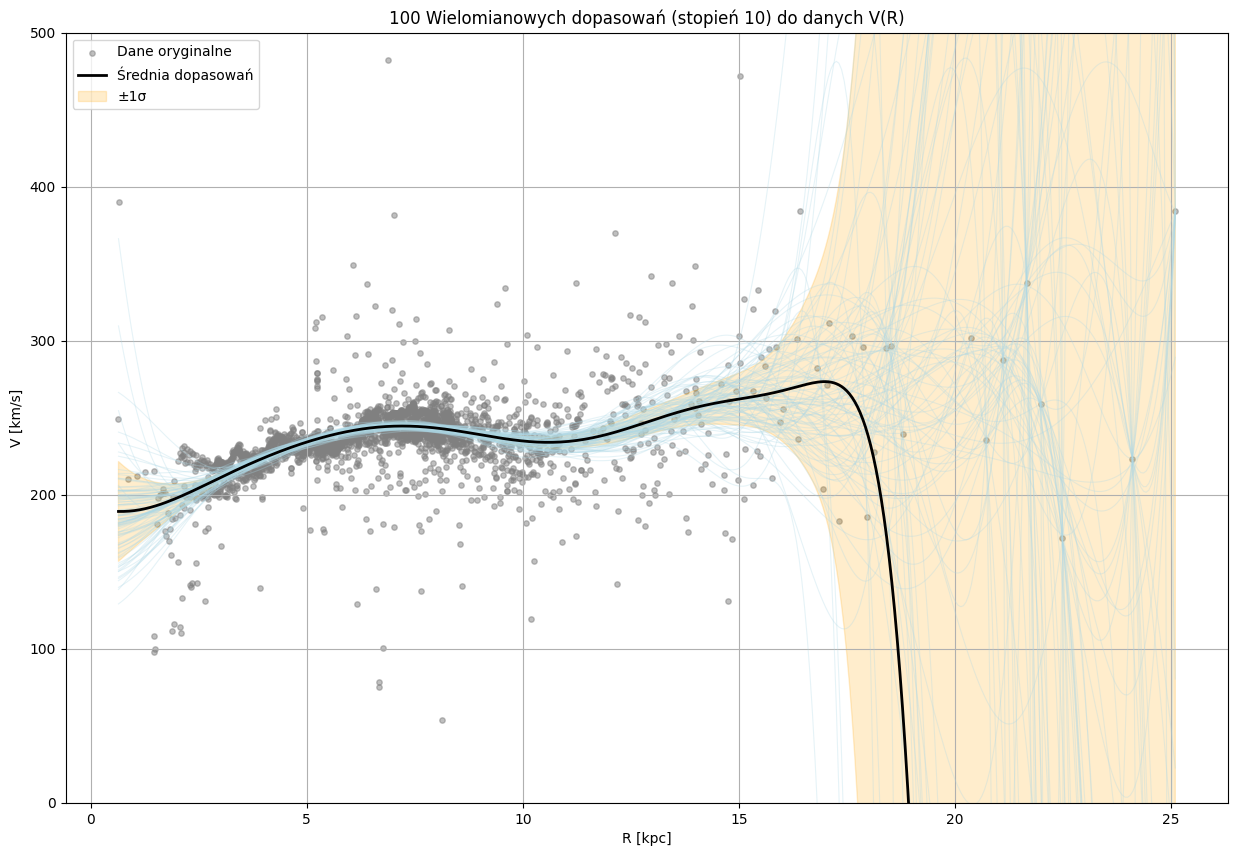

Średnia standardowa odchylenia dopasowań: 32227.917


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",
    usecols=["R", "V"]
).dropna(subset=["R", "V"])

R_all = df["R"].values
V_all = df["V"].values

# parametry
n_samples = 100       # ile podzbiorów losuje
n_events = 500         # ile punktów losuje w jednym podzbiorze
degree = 10            # stopień wielomianu
R_pred = np.linspace(R_all.min(), R_all.max(), 400)  # zakres predykcji

# pętla dopasowań
all_fits = []

plt.figure(figsize=(15, 10))
plt.scatter(R_all, V_all, color="gray", s=15, alpha=0.5, label="Dane oryginalne")

np.random.seed(42)
for i in range(n_samples):
    # losowy podzbiór punktów
    idx = np.random.choice(len(R_all), size=n_events, replace=False)
    R_sample = R_all[idx].reshape(-1, 1)
    V_sample = V_all[idx]

    # model wielomianowy
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])
    model.fit(R_sample, V_sample)

    # predykcja na pełnym zakresie
    V_fit = model.predict(R_pred.reshape(-1, 1))
    all_fits.append(V_fit)

    # wykres pojedynczego dopasowania
    plt.plot(R_pred, V_fit, color='lightblue', alpha=0.3, linewidth=0.8)

# średnia dopasowań
average_fit = np.mean(all_fits, axis=0)
plt.plot(R_pred, average_fit, color='black', linewidth=2, label='Średnia dopasowań')

# pas niepewności ±1σ
fit_std = np.std(all_fits, axis=0)
plt.fill_between(R_pred, average_fit - fit_std, average_fit + fit_std, color='orange', alpha=0.2, label='±1σ')

# wykres
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title(f"{n_samples} Wielomianowych dopasowań (stopień {degree}) do danych V(R)")
plt.legend()
plt.grid(True)
plt.ylim(0, 500)
plt.show()

# statystyki
avg_std = np.mean(fit_std)
print(f"Średnia standardowa odchylenia dopasowań: {avg_std:.3f}")

Running 20 fits on random subsets of 400 points each...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.3. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.3. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


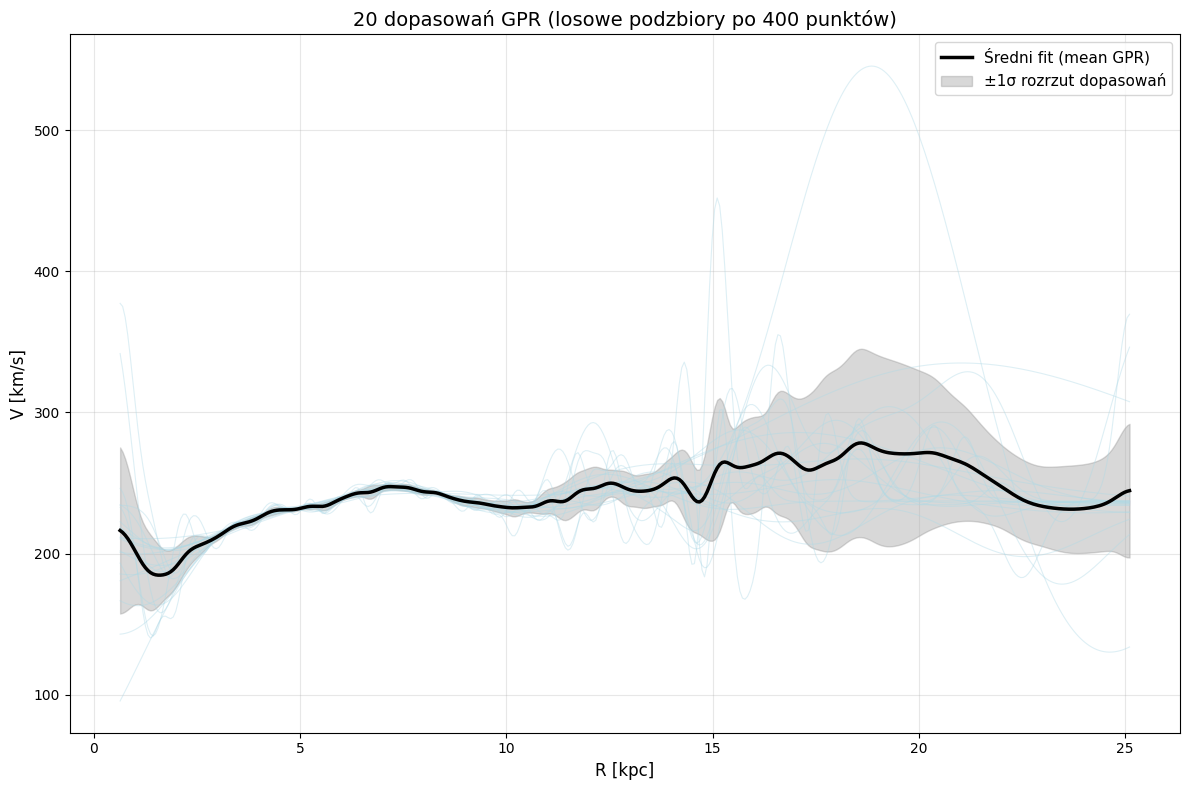


Średnie odchylenie standardowe między dopasowaniami: 23.737


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",
    usecols=["R", "V"]
).dropna(subset=["R", "V"])

# parametry
n_samples = 20          # ile razy powtórzyć dopasowanie
subset_size = 400       # ile punktów losować w każdym dopasowaniu
random_state = 42

# przygotowanie danych
R_all = df["R"].values.reshape(-1, 1)
V_all = df["V"].values

R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)

# kernel
kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=3.0, length_scale_bounds=(0.3, 30.0)) \
         + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-4, 5.0))

# wykres
plt.figure(figsize=(15, 10))
all_preds = []

print(f"Running {n_samples} fits on random subsets of {subset_size} points each...")

for i in range(n_samples):
    # losowy podzbiór danych
    np.random.seed(random_state + i)
    idx = np.random.choice(len(R_all), subset_size, replace=False)
    R_sub, V_sub = R_all[idx], V_all[idx]

    # dopasowanie modelu
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True, n_restarts_optimizer=2)
    gpr.fit(R_sub, V_sub)

    # predykcja
    V_pred, _ = gpr.predict(R_pred, return_std=True)
    all_preds.append(V_pred)

    plt.plot(R_pred, V_pred, color='lightblue', alpha=0.4, linewidth=0.8)

# średni fit i odchylenie
all_preds = np.array(all_preds)
mean_pred = np.mean(all_preds, axis=0)
std_pred = np.std(all_preds, axis=0)

plt.plot(R_pred, mean_pred, color='black', linewidth=2.5, label='Średni fit (mean GPR)')
plt.fill_between(R_pred.ravel(), mean_pred-std_pred, mean_pred+std_pred,
                 color='gray', alpha=0.3, label='±1σ rozrzut dopasowań')

plt.xlabel("R [kpc]", fontsize=12)
plt.ylabel("V [km/s]", fontsize=12)
plt.title(f"{n_samples} dopasowań GPR (losowe podzbiory po {subset_size} punktów)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# statystyka
avg_std = np.mean(std_pred)
print(f"\nŚrednie odchylenie standardowe między dopasowaniami: {avg_std:.3f}")

# Regresja Gaussa

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/r_v_montecarlo.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)
print(df_all.head())

         R          V
0  2.16208  205.52478
1  2.30257  200.57954
2  2.44236  196.41595
3  2.58141  197.63277
4  2.71967  197.12877


/tmp/ipython-input-904907318.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


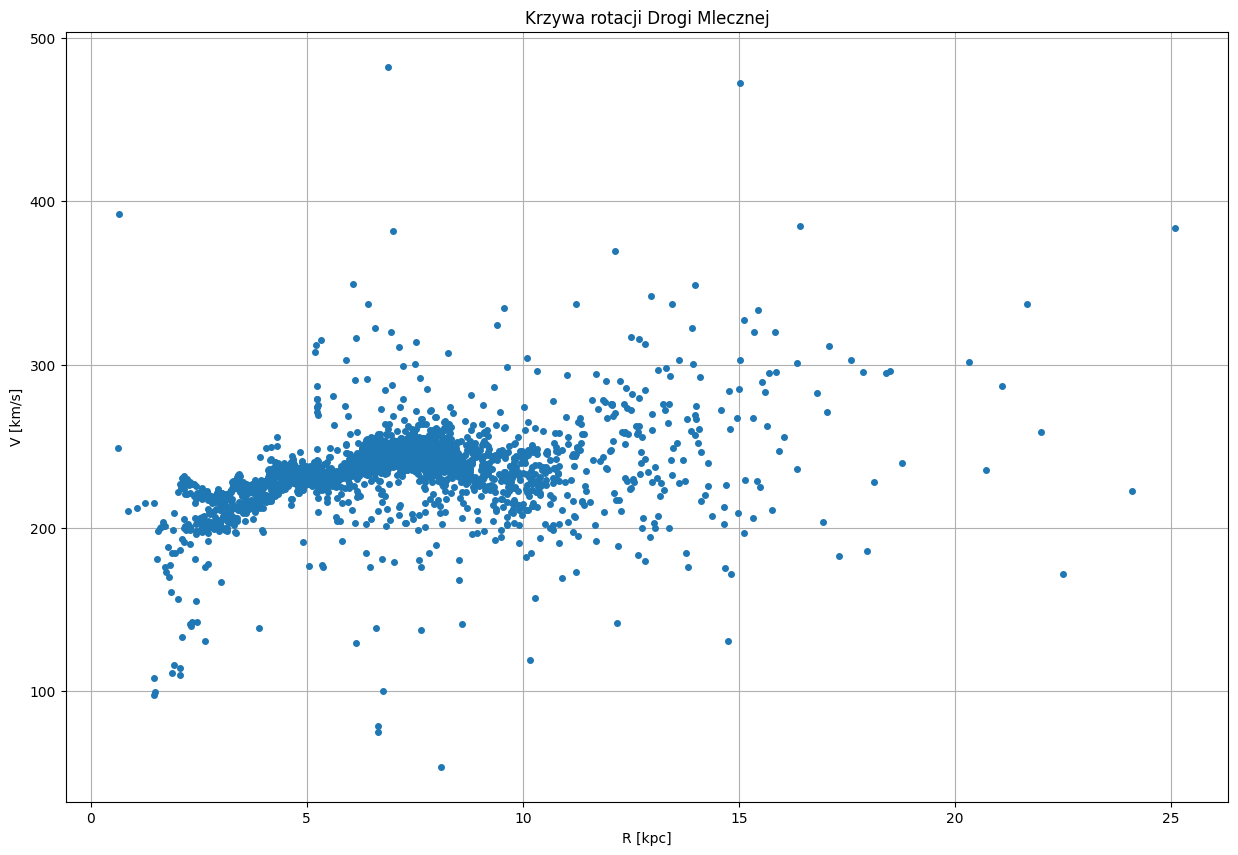

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# wykres R vs V
plt.figure(figsize=(15,10))
plt.plot(df_all["R"], df_all["V"], 'o', markersize=4)
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Krzywa rotacji Drogi Mlecznej")
plt.grid(True)
plt.show()

Dopasowane parametry: a=254.82, b=15.20, c=22.46


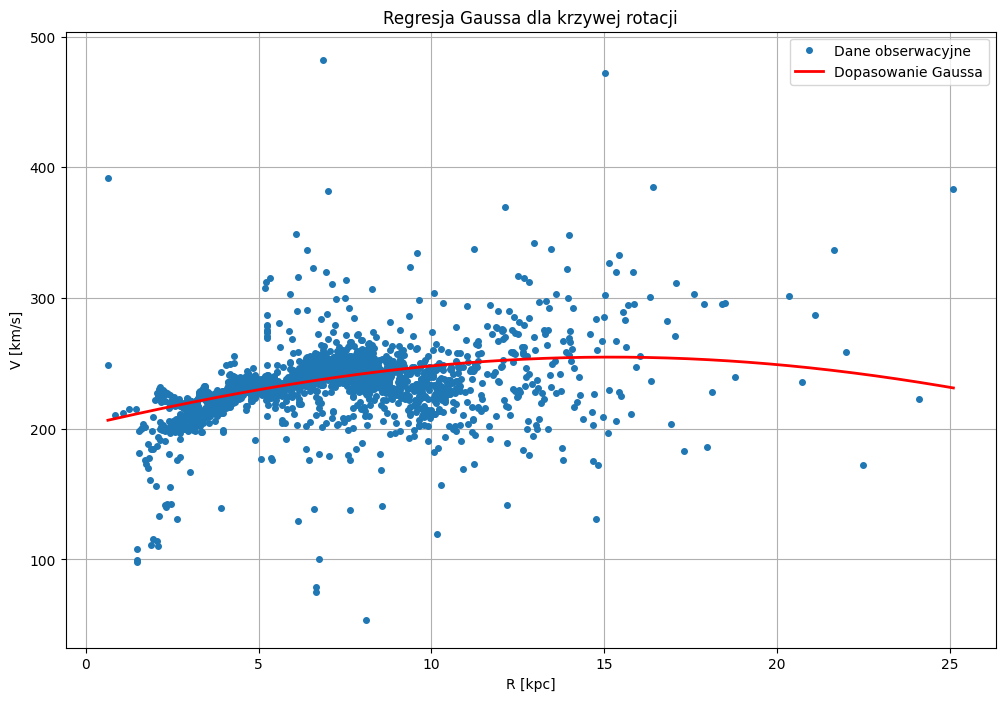

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# definicja funkcji gaussa z wzoru
def gauss(R, a, b, c):
    return a * np.exp(-((R - b)**2) / (2 * c**2))

# dopasowanie modelu do danych
R = df_all["R"].values
V = df_all["V"].values

p0 = [230, 8, 2]  # początkowe parametry: amplituda, środek, szerokość

params, cov = curve_fit(gauss, R, V, p0=p0) # dopasowanie - opis poniżej

a, b, c = params # parametry dopasowania
print(f"Dopasowane parametry: a={a:.2f}, b={b:.2f}, c={c:.2f}")

# dopasowanie R i V do wykresu
R_fit = np.linspace(R.min(), R.max(), 500)
V_fit = gauss(R_fit, *params)

# wykres
plt.figure(figsize=(12,8))
plt.plot(R, V, 'o', markersize=4, label='Dane obserwacyjne')
plt.plot(R_fit, V_fit, 'r-', linewidth=2, label='Dopasowanie Gaussa')
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Regresja Gaussa dla krzywej rotacji")
plt.legend()
plt.grid(True)
plt.show()

curve_fit z scipy.optimize służy do dopasowania dowolnej funkcji matematycznej do danych metodą nieliniowych najmniejszych kwadratów

* funkcja - to funkcja, którą chcesz dopasować, np. gauss(R, a, b, c). Musi przyjmować pierwszy argument jako x (tu R), a kolejne jako parametry dopasowywane (a, b, c).
* xdata, ydata - dane eksperymentalne: xdata - wartości niezależne (promień galaktocentryczny R [kpc]), ydata - wartości zależne (prędkość rotacji V [km/s])
* p0 - initial guess - początkowe przybliżenie parametrów

# Gaussian Process Regression

**ConstantKernel(1.0, (1e-3, 1e3))** to amplituda (czyli ogólna skala wartości funkcji). Wartość 1.0 oznacza, że model zaczyna z amplitudą 1. Zakres (1e-3, 1e3) mówi, że optymalizator może zmieniać tę amplitudę między 0.001 a 1000. Kontroluje to „wysokość” przewidywanej funkcji oraz określa „ile” zmienności ma model, czy dane są niemal płaskie, czy mają duże amplitudy zmian

**RBF(length_scale=0.3, length_scale_bounds=(0.1, 10.0))** to tzw. Radial Basis Function kernel, znany też jako Gaussian kernel. To on decyduje, jak gładka jest funkcja dopasowania.
length_scale to długość skali (czyli odległość, na której punkty są jeszcze ze sobą skorelowane). Mała wartość sprawia, że krzywa dopasowuje się bardzo lokalnie (falowanie, dopasowanie do szumu). Duża wartość sprawie, że krzywa jest gładka i reaguje tylko na duże zmiany trendu.
length_scale_bounds to zakres wartości, w jakim optymalizator może szukać najlepszej długości skali.

**WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))** to składnik szumowy, który modeluje niepewność lub rozrzut danych. Dzięki temu GPR nie stara się idealnie dopasować każdego punktu, tylko uwzględnia, że dane są „hałaśliwe”.
noise_level to początkowy poziom szumu (wariancja błędu).
noise_level_bounds to zakres dopuszczalnych wartości podczas dopasowania.

# Gaussian Process Regression - R, V

length_scale=2.0

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

# tylko kolumny R i V
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",   # pomija wiersze z błędami formatowania
    usecols=["R", "V"]     # tylko potrzebne kolumny
)

# usunięcie pojawiających się NaN-y
df = df.dropna(subset=["R", "V"])

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)
V = df["V"].values

# definicja jądra (kernel)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=2.0, length_scale_bounds=(0.1, 20.0)) \
          + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))

# dopasowanie modelu GPR
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, n_restarts_optimizer=5, normalize_y=True)
gpr.fit(R, V)

print("\nDopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcja na gęstej siatce R
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)



Dopasowane jądro (kernel):
1.29**2 * RBF(length_scale=0.198) + WhiteKernel(noise_level=0.65)


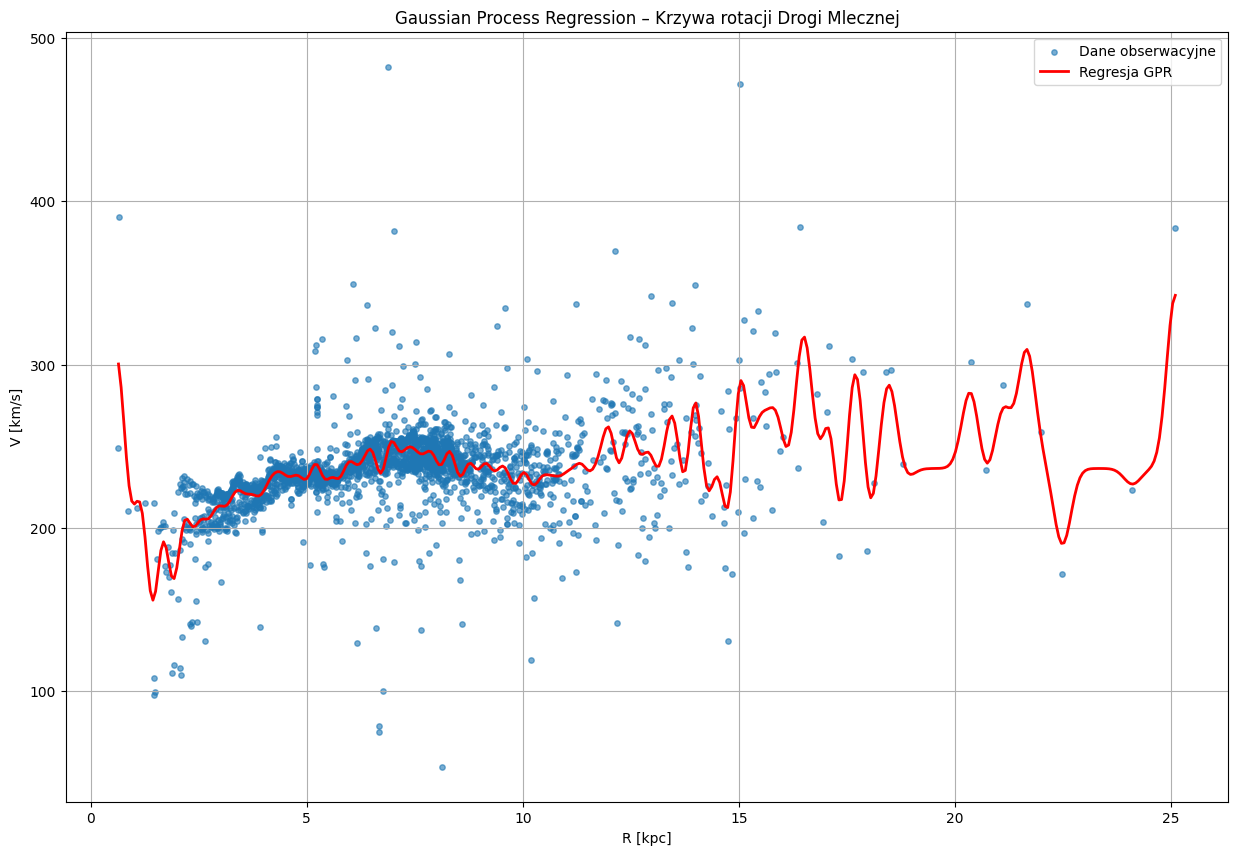

In [24]:
# wykres
plt.figure(figsize=(15, 10))
plt.scatter(R, V, color='tab:blue', s=15, label='Dane obserwacyjne', alpha=0.6)
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')


plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – Krzywa rotacji Drogi Mlecznej")
plt.legend()
plt.grid(True)
plt.show()

length_scale=0.3


Dopasowane jądro (kernel):
1.29**2 * RBF(length_scale=0.198) + WhiteKernel(noise_level=0.65)


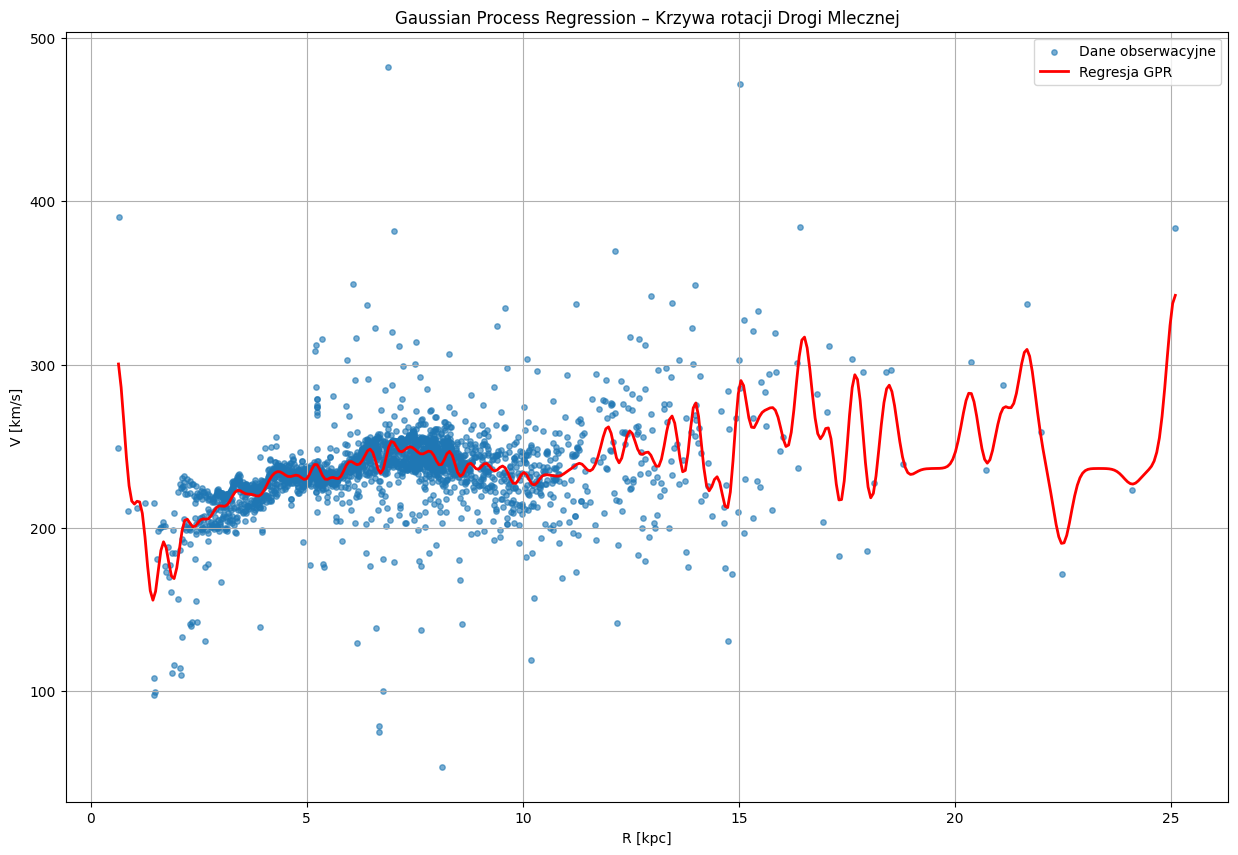

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

# tylko kolumny R i V
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",   # pomija wiersze z błędami formatowania
    usecols=["R", "V"]     # tylko potrzebne kolumny
)

# usunięcie pojawiających się NaN-y
df = df.dropna(subset=["R", "V"])

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)
V = df["V"].values

# definicja jądra (kernel)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.3, length_scale_bounds=(0.1, 10.0)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
# dopasowanie modelu GPR
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, n_restarts_optimizer=5, normalize_y=True)
gpr.fit(R, V)

print("\nDopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcja na gęstej siatce R
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)

# wykres
plt.figure(figsize=(15, 10))
plt.scatter(R, V, color='tab:blue', s=15, label='Dane obserwacyjne', alpha=0.6)
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')


plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – Krzywa rotacji Drogi Mlecznej")
plt.legend()
plt.grid(True)
plt.show()


length_scale=15


Dopasowane jądro (kernel):
1.29**2 * RBF(length_scale=0.198) + WhiteKernel(noise_level=0.65)


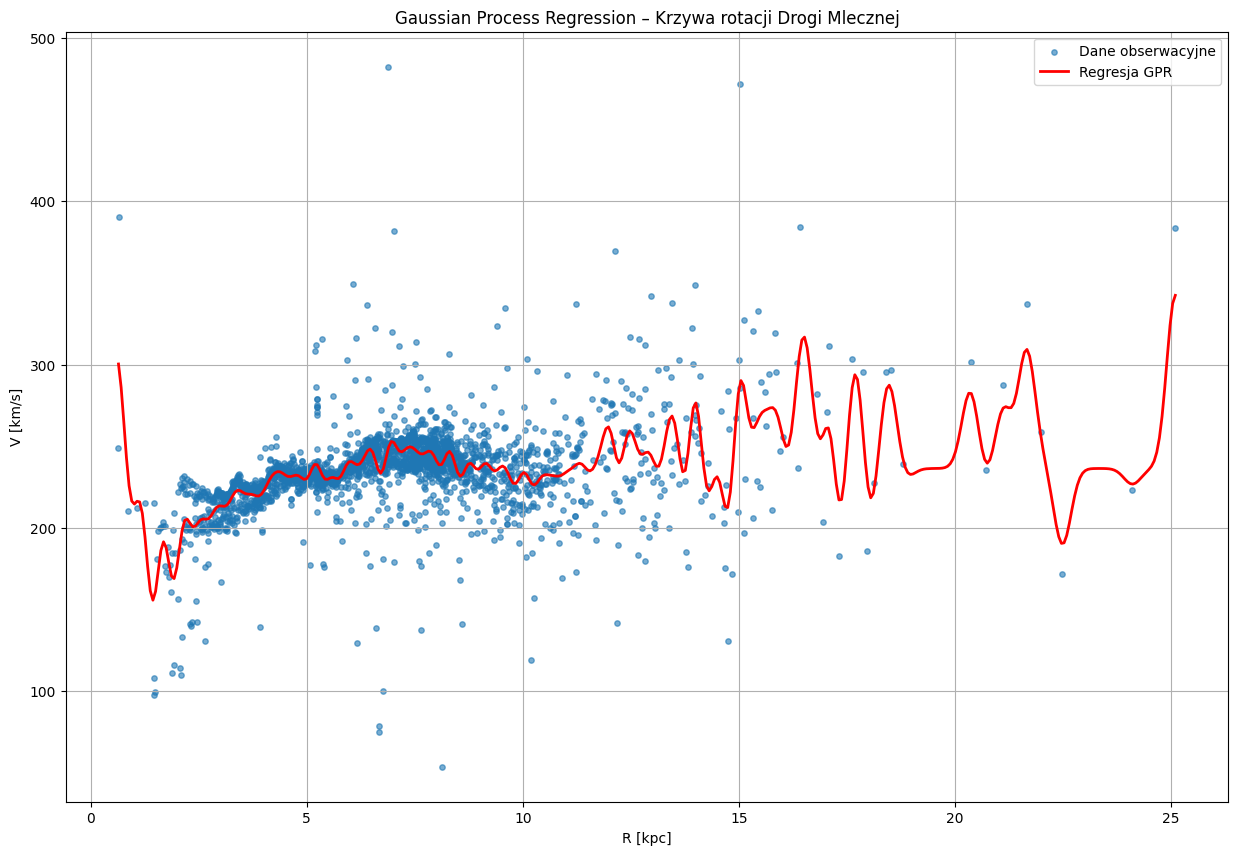

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

# tylko kolumny R i V
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",   # pomija wiersze z błędami formatowania
    usecols=["R", "V"]     # tylko potrzebne kolumny
)

# usunięcie pojawiających się NaN-y
df = df.dropna(subset=["R", "V"])

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)
V = df["V"].values

# definicja jądra (kernel)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=15, length_scale_bounds=(0.1, 10.0)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
# dopasowanie modelu GPR
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, n_restarts_optimizer=5, normalize_y=True)
gpr.fit(R, V)

print("\nDopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcja na gęstej siatce R
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)

# wykres
plt.figure(figsize=(15, 10))
plt.scatter(R, V, color='tab:blue', s=15, label='Dane obserwacyjne', alpha=0.6)
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')


plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – Krzywa rotacji Drogi Mlecznej")
plt.legend()
plt.grid(True)
plt.show()


Porównanie różnych length_scale -> nic to nie daje

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",
    usecols=["R", "V"]
)
df = df.dropna(subset=["R", "V"])

R = df["R"].values.reshape(-1, 1)
V = df["V"].values

# zakres promieni do predykcji w tych samych jednostkach co dane
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)

# konfiguracje kernela do porównania
kernels = [
    ("length_scale=0.3",
     ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.3, length_scale_bounds=(0.1, 10.0)) +
     WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
    ),
    ("length_scale=1.0",
     ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0)) +
     WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
    ),
    ("length_scale=3.0",
     ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=3.0, length_scale_bounds=(0.1, 10.0)) +
     WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
    ),
    ("length_scale=6.0",
     ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=6.0, length_scale_bounds=(0.1, 10.0)) +
     WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10))
    )
]

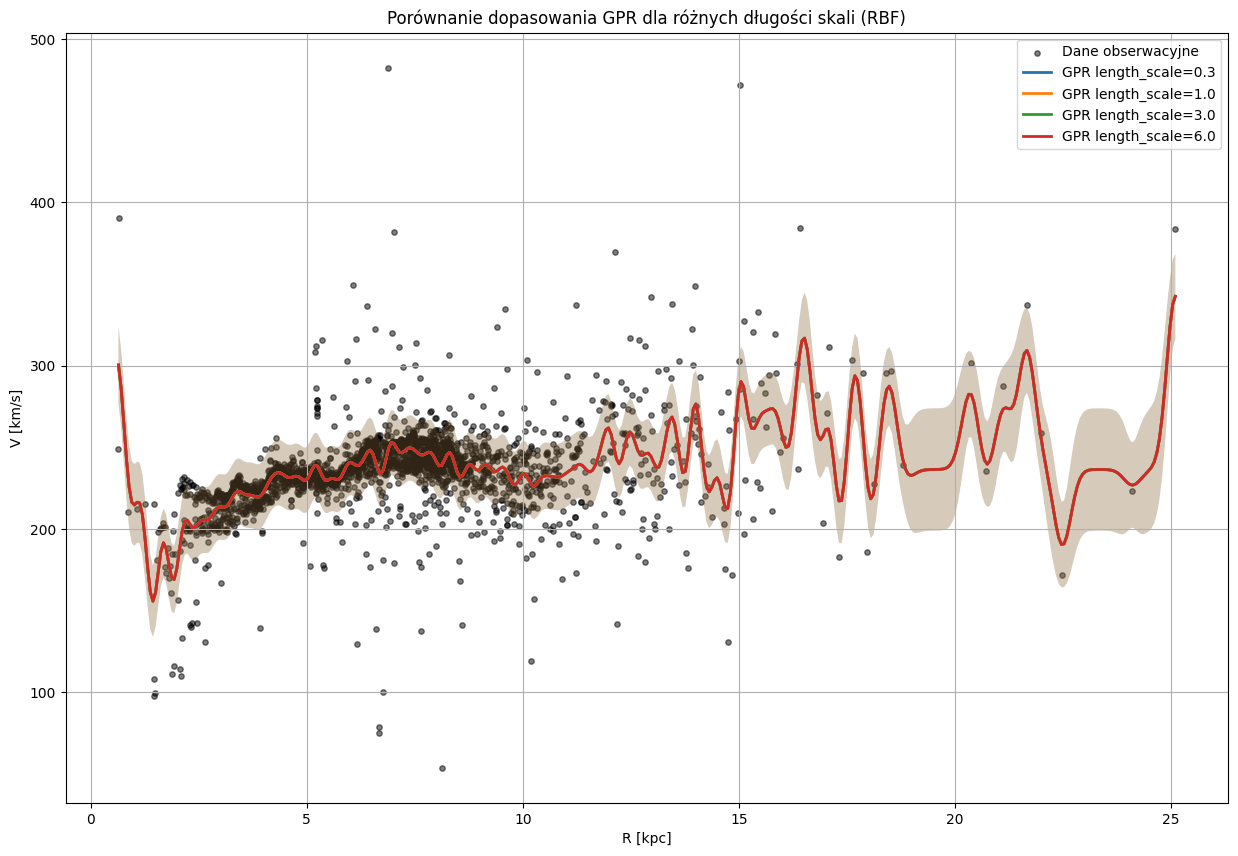

In [38]:

# wykres
plt.figure(figsize=(15, 10))
plt.scatter(R, V, color="black", s=15, label="Dane obserwacyjne", alpha=0.5)

# dopasowanie i rysowanie każdego modelu
for label, kernel in kernels:
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, normalize_y=True)
    gpr.fit(R, V)
    V_pred, V_std = gpr.predict(R_pred, return_std=True)
    plt.plot(R_pred, V_pred, lw=2, label=f"GPR {label}")
    plt.fill_between(R_pred.ravel(), V_pred - V_std, V_pred + V_std, alpha=0.1)

plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Porównanie dopasowania GPR dla różnych długości skali (RBF)")
plt.legend()
plt.grid(True)
plt.show()

noise_level 0.5


Dopasowane jądro (kernel):
1.29**2 * RBF(length_scale=0.198) + WhiteKernel(noise_level=0.65)


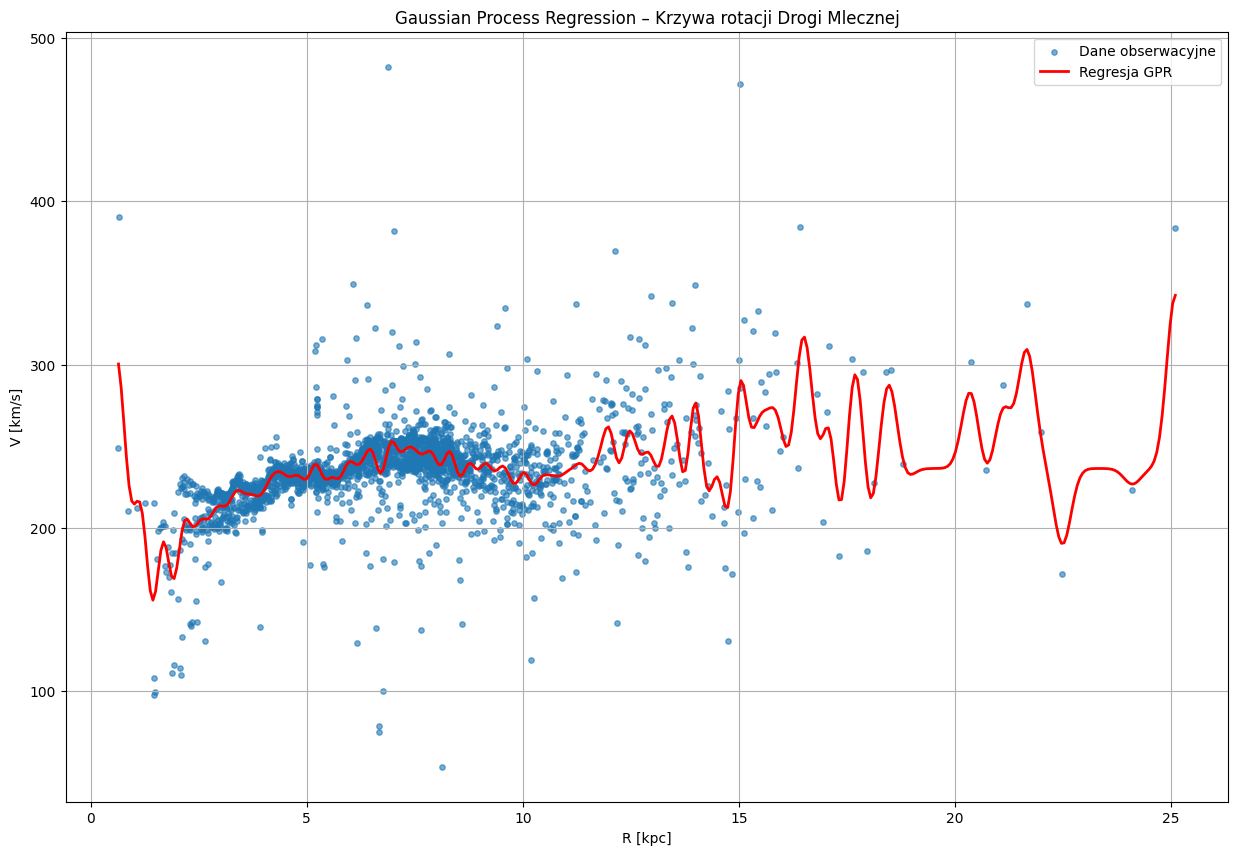

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

# tylko kolumny R i V
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",   # pomija wiersze z błędami formatowania
    usecols=["R", "V"]     # tylko potrzebne kolumny
)

# usunięcie pojawiających się NaN-y
df = df.dropna(subset=["R", "V"])

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)
V = df["V"].values

# definicja jądra (kernel)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=15, length_scale_bounds=(0.1, 10.0)) + WhiteKernel(noise_level=0.5, noise_level_bounds=(1e-5, 10))
# dopasowanie modelu GPR
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, n_restarts_optimizer=5, normalize_y=True)
gpr.fit(R, V)

print("\nDopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcja na gęstej siatce R
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)

# wykres
plt.figure(figsize=(15, 10))
plt.scatter(R, V, color='tab:blue', s=15, label='Dane obserwacyjne', alpha=0.6)
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')


plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – Krzywa rotacji Drogi Mlecznej")
plt.legend()
plt.grid(True)
plt.show()

noise_level 1.0


Dopasowane jądro (kernel):
1.29**2 * RBF(length_scale=0.198) + WhiteKernel(noise_level=0.65)


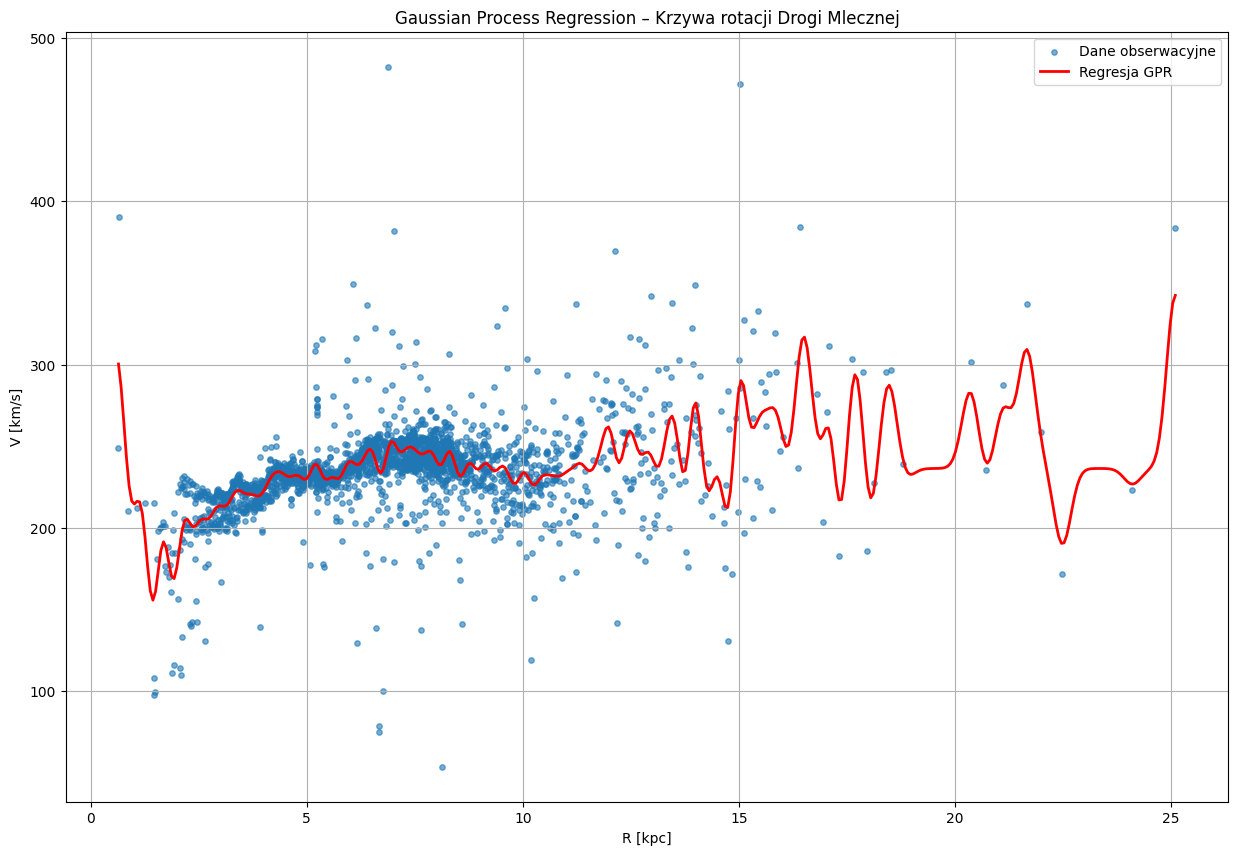

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

# tylko kolumny R i V
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",   # pomija wiersze z błędami formatowania
    usecols=["R", "V"]     # tylko potrzebne kolumny
)

# usunięcie pojawiających się NaN-y
df = df.dropna(subset=["R", "V"])

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)
V = df["V"].values

# definicja jądra (kernel)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=15, length_scale_bounds=(0.1, 10.0)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 10))
# dopasowanie modelu GPR
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, n_restarts_optimizer=5, normalize_y=True)
gpr.fit(R, V)

print("\nDopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcja na gęstej siatce R
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)

# wykres
plt.figure(figsize=(15, 10))
plt.scatter(R, V, color='tab:blue', s=15, label='Dane obserwacyjne', alpha=0.6)
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')


plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – Krzywa rotacji Drogi Mlecznej")
plt.legend()
plt.grid(True)
plt.show()

Rows: 2805
                 R            V
count  2805.000000  2805.000000
mean      6.935866   236.408858
std       2.853863    24.623386
min       0.642550    53.773720
25%       4.983630   227.025050
50%       6.902210   236.697070
75%       8.236790   248.032630
max      25.104690   482.411910
After cleaning rows: 2805 R range: 0.64255 25.10469

--- FITTING: small_ls  initial kernel: 1**2 * RBF(length_scale=0.2) + WhiteKernel(noise_level=0.01)
Fitted kernel: 1.29**2 * RBF(length_scale=0.0694) + WhiteKernel(noise_level=0.65)
Train RMSE for small_ls: 19.534 km/s

--- FITTING: medium_ls  initial kernel: 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.1)
Fitted kernel: 1.29**2 * RBF(length_scale=0.0694) + WhiteKernel(noise_level=0.65)
Train RMSE for medium_ls: 19.534 km/s

--- FITTING: large_ls  initial kernel: 1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Fitted kernel: 1.38**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.668)
Train RMSE for large_ls: 19.876 km/s


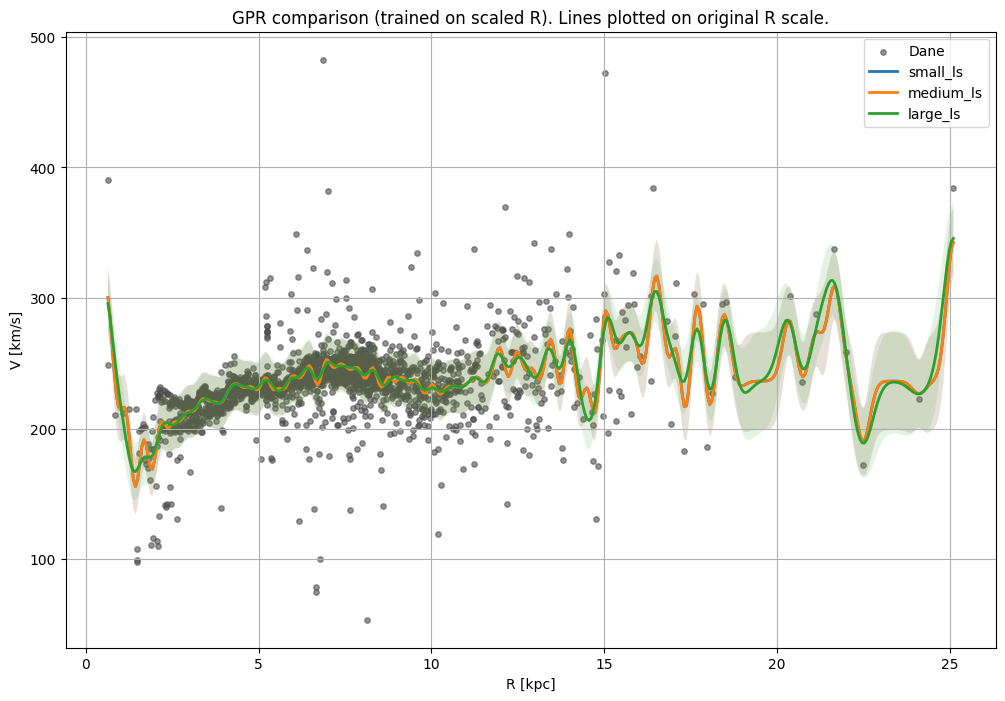


Summary:
small_ls -> kernel: 1.29**2 * RBF(length_scale=0.0694) + WhiteKernel(noise_level=0.65)  RMSE: 19.53405877030287
medium_ls -> kernel: 1.29**2 * RBF(length_scale=0.0694) + WhiteKernel(noise_level=0.65)  RMSE: 19.53405902577065
large_ls -> kernel: 1.38**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.668)  RMSE: 19.875714529594617


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import mean_squared_error

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"
df = pd.read_csv(file_path, sep=r"\s+", comment="#", on_bad_lines="skip", usecols=["R", "V"])
df = df.dropna(subset=["R","V"]).copy()

print("Rows:", len(df)) # liczba wierszy
print(df[["R","V"]].describe()) # statystyczne podsumowanie kolumn

# usunięcie pojawiających się NaN-y i absurdalnych R jeśli są
df = df[(df["R"] > 0) & (df["R"] < 40)].copy()   # R jest mniejsze niż 40 kpc
print("After cleaning rows:", len(df), "R range:", df["R"].min(), df["R"].max())

# przygotowanie danych
R = df["R"].values.reshape(-1,1)
V = df["V"].values

# skalowanie R do jednostek znormalizowanych, aby ułatwić dobór length_scale
scaler = StandardScaler()
R_s = scaler.fit_transform(R)

# siatka predykcji w oryginalnej skali do rysunku
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1,1)
R_pred_s = scaler.transform(R_pred)  # przeskalowane dla predykcji na skalowanych danych

# kernels do porównania, length_scale w skali znormalizowanej
kern_cfg = [
    ("small_ls", ConstantKernel(1.0,(1e-3,1e3))*RBF(0.2, length_scale_bounds=(1e-2,5.0)) + WhiteKernel(0.01, (1e-6, 10))),
    ("medium_ls", ConstantKernel(1.0,(1e-3,1e3))*RBF(1.0, length_scale_bounds=(1e-2,10.0)) + WhiteKernel(0.1, (1e-6, 10))),
    ("large_ls", ConstantKernel(1.0,(1e-3,1e3))*RBF(5.0, length_scale_bounds=(1e-1,20.0)) + WhiteKernel(1.0, (1e-6, 100)))
]

plt.figure(figsize=(12,8))
plt.scatter(R, V, color="0.3", s=15, alpha=0.6, label="Dane")

# pętla, która automatycznie trenuje i porównuje kilka modeli Gaussian Process Regression
results = []
for label, kernel in kern_cfg:
    print("\n--- FITTING:", label, " initial kernel:", kernel) # wypisaniee kernela który jest liczony
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=5, normalize_y=True, random_state=42) # model GPR z danym kernelem z optymalizacja
    gpr.fit(R_s, V) # R_s jest skalowane żeby model lepiej działał
    print("Fitted kernel:", gpr.kernel_) # opis dopasowanego kernela

    # predykcja w skali, na której model był uczony (R_s)
    V_pred, V_std = gpr.predict(R_pred_s, return_std=True) # dodatkowo odchylenie standardowe
    plt.plot(R_pred, V_pred, lw=2, label=f"{label}") # krzywa
    plt.fill_between(R_pred.ravel(), V_pred - V_std, V_pred + V_std, alpha=0.12) # niepewność
    V_train_pred = gpr.predict(R_s)
    rmse = np.sqrt(mean_squared_error(V, V_train_pred)) # błąd średniokwadratowy (RMSE), czyli jaka róźnica modelu względem danych
    print(f"Train RMSE for {label}: {rmse:.3f} km/s")
    results.append((label, gpr.kernel_, rmse)) # zapisanie danych kazdego kernela

# wykres
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("GPR comparison (trained on scaled R). Lines plotted on original R scale.")
plt.legend()
plt.grid(True)
plt.show()

print("\nSummary:")
for r in results:
    print(r[0], "-> kernel:", r[1], " RMSE:", r[2])

Ten obrazek powtarza się kilka razy. W tym dopasowaniu funkcji widać, że funkcja silnie fluktuuje wokół punktów, do których jest dopasowana i chyba nie generalizuje zjawiska. Przebieg funkcji losowo zależy od tego, które punkty weźmiemy do fitu. Założę sie, że jeśli weżmie Pani losowo kilka razy np 2/3 wszystkich punktów (za każdym razem innych, wybranych losowo) dostanie pani zupełnie inną funkcję. W stabilnym dopasowaniu funkcji wynik powinien nie być silnie zależny od tego, które punkty bierzemy do dopasowania. Musi być gładsza ta funkcja. Na tym rysunku pokazuje Pani, że GPR length wogóle nie zmienia przebiegu funkcji V Moim zdaniem stabilny fit to taki, który nie zmienia się jeśli wyrzuci Pani np. 10% przypadkowo wybranych punktów W Pani przykładzie wygląda to na overfitting. Sprawdza się to np. poprzez cross-validation. Przykładowo, dzieli Pani dane na dwie części, wykonuje dopasowanie dla jednej części danych i oblicza MSE. Następnie oblicza się MSE względem dokładnie tej samej funkcji, dopasowanej do pierwszej części danych, wzgłędem drugiej części. Wyniki powinny być podobne


Poniżej sprawdzenie czy model się nie przeucza:

MSE (train): 361.121
MSE (test):  386.469
Dopasowany kernel: 1.19**2 * RBF(length_scale=1.17) + WhiteKernel(noise_level=0.678)


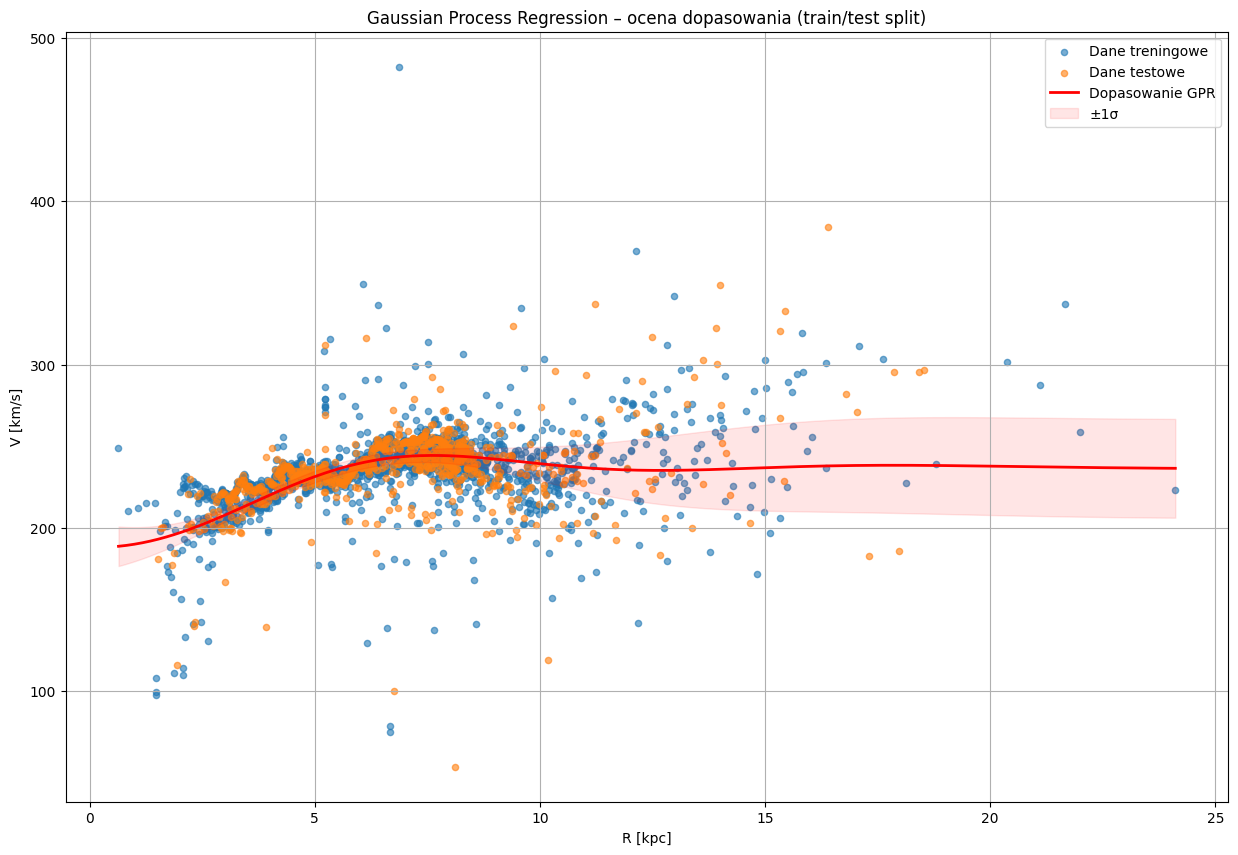

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",
    usecols=["R", "V"]
)

# podział danych 70/30
R_train, R_test, V_train, V_test = train_test_split(R, V, test_size=0.3, random_state=42)

# GPR z "rozsądniejszymi" parametrami (bardziej gładkie dopasowanie)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=10, length_scale_bounds=(0.1, 50.0)) \
         + WhiteKernel(noise_level=2.0, noise_level_bounds=(1e-5, 10))

gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
gpr.fit(R_train, V_train)

# predykcja
V_pred_train = gpr.predict(R_train)
V_pred_test = gpr.predict(R_test)

# błędy
mse_train = mean_squared_error(V_train, V_pred_train)
mse_test = mean_squared_error(V_test, V_pred_test)

print(f"MSE (train): {mse_train:.3f}")
print(f"MSE (test):  {mse_test:.3f}")
print("Dopasowany kernel:", gpr.kernel_)

# wykres
plt.figure(figsize=(15, 10))

# punkty trenigowe
plt.scatter(R_train, V_train, color="tab:blue", s=20, label="Dane treningowe", alpha=0.6)
# punkty testowe
plt.scatter(R_test, V_test, color="tab:orange", s=20, label="Dane testowe", alpha=0.6)
# krzywa modelu GPR
plt.plot(R_pred, V_pred, "r-", lw=2, label="Dopasowanie GPR")
# niepewność (±1σ)
plt.fill_between(R_pred.ravel(), V_pred - V_std, V_pred + V_std, color="red", alpha=0.1, label="±1σ")

plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – ocena dopasowania (train/test split)")
plt.legend()
plt.grid(True)
plt.show()

MSE (train): 361.121
MSE (test):  386.469
Dopasowany kernel: 1.19**2 * RBF(length_scale=1.17) + WhiteKernel(noise_level=0.678)


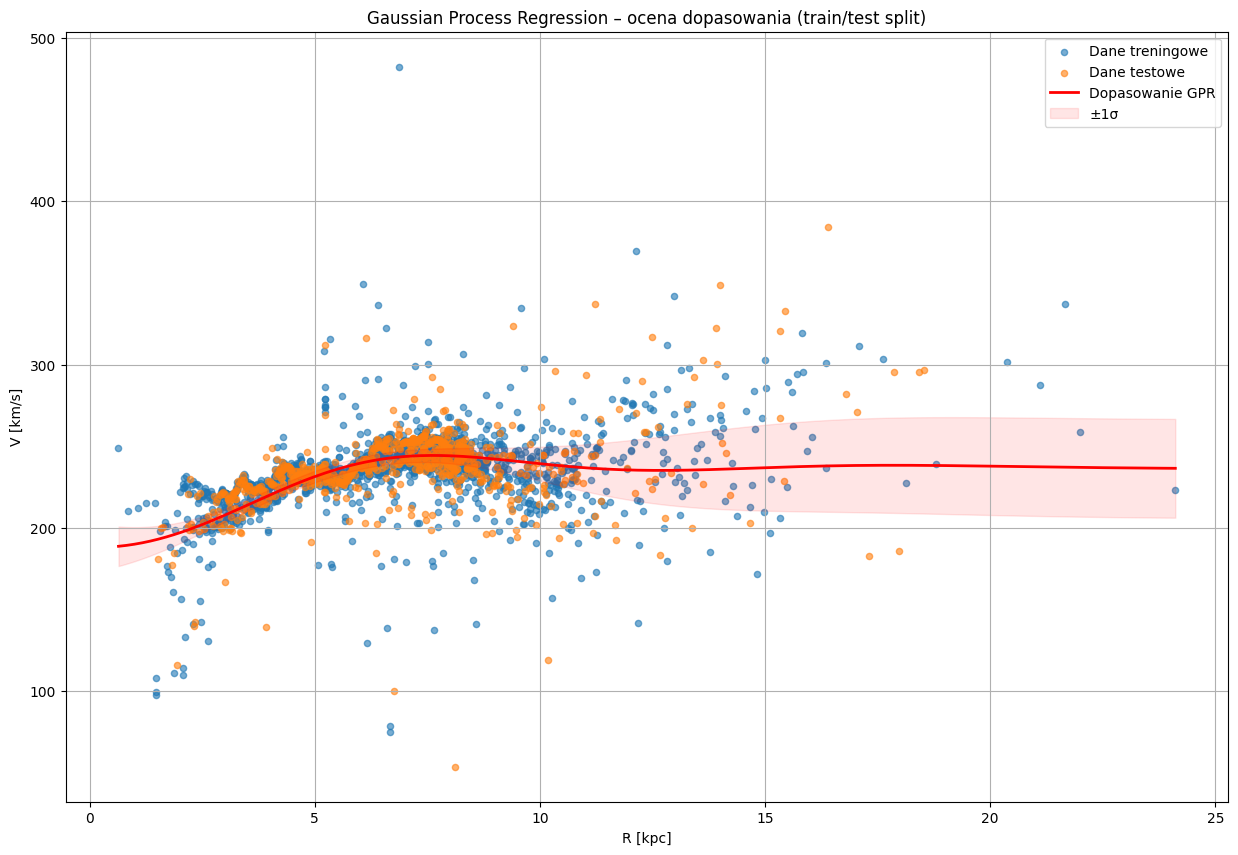

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",
    usecols=["R", "V"]
)

# podział danych 70/30
R_train, R_test, V_train, V_test = train_test_split(R, V, test_size=0.3, random_state=42)

# GPR z "rozsądniejszymi" parametrami (bardziej gładkie dopasowanie)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=5, length_scale_bounds=(0.1, 50.0)) \
         + WhiteKernel(noise_level=5.0, noise_level_bounds=(1e-5, 50))

gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
gpr.fit(R_train, V_train)

# predykcja
V_pred_train = gpr.predict(R_train)
V_pred_test = gpr.predict(R_test)

# błędy
mse_train = mean_squared_error(V_train, V_pred_train)
mse_test = mean_squared_error(V_test, V_pred_test)

print(f"MSE (train): {mse_train:.3f}")
print(f"MSE (test):  {mse_test:.3f}")
print("Dopasowany kernel:", gpr.kernel_)

# wykres
plt.figure(figsize=(15, 10))

# punkty trenigowe
plt.scatter(R_train, V_train, color="tab:blue", s=20, label="Dane treningowe", alpha=0.6)
# punkty testowe
plt.scatter(R_test, V_test, color="tab:orange", s=20, label="Dane testowe", alpha=0.6)
# krzywa modelu GPR
plt.plot(R_pred, V_pred, "r-", lw=2, label="Dopasowanie GPR")
# niepewność (±1σ)
plt.fill_between(R_pred.ravel(), V_pred - V_std, V_pred + V_std, color="red", alpha=0.1, label="±1σ")

plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – ocena dopasowania (train/test split)")
plt.legend()
plt.grid(True)
plt.show()

# Gaussian Process Regression - R, V, dV

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



 Dopasowane jądro (kernel):
1.2**2 * RBF(length_scale=3.68) + WhiteKernel(noise_level=1e-05)


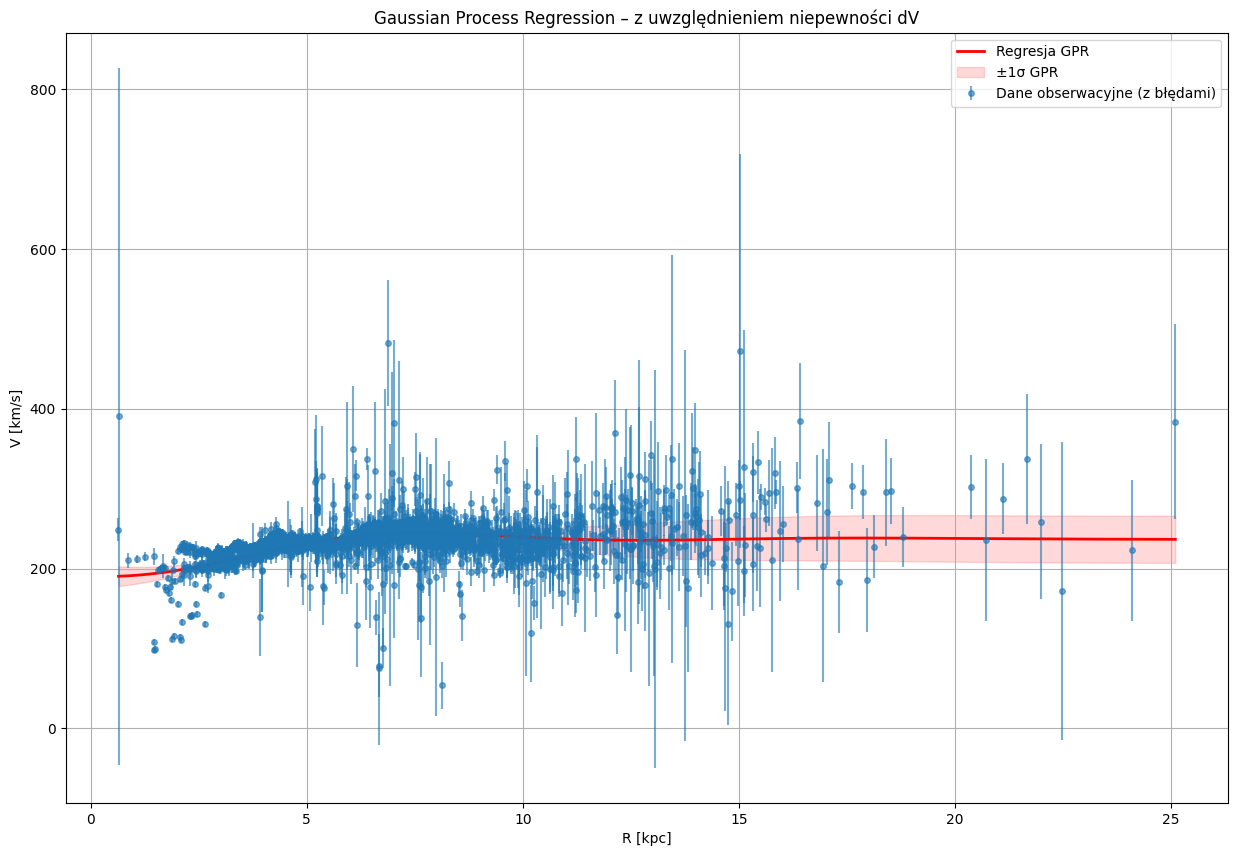

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",
    usecols=["R", "V", "dV"]   # <-- dodajemy kolumnę niepewności
)

# usunięcie pojawiających się NaN-y
df = df.dropna(subset=["R", "V", "dV"])

# filtrowanie sensownych zakresów
df = df[(df["R"] > 0) & (df["R"] < 100)].copy()

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)
V = df["V"].values
dV = df["dV"].values

# definicja kernela
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * RBF(length_scale=10, length_scale_bounds=(0.1, 50.0))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 10))
)

# dopasowanie modelu GPR z błędami pomiarowymi
gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=dV**2, # alpha przyjmuje wariancje szumów (dV^2)
    n_restarts_optimizer=5,
    normalize_y=True,
    random_state=42
)
gpr.fit(R, V)

print("\n Dopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcja na gęstej siatce R
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)

# wykres
plt.figure(figsize=(15, 10))
plt.errorbar(R.ravel(), V, yerr=dV, fmt='o', color='tab:blue', ms=4, alpha=0.6,
             label='Dane obserwacyjne (z błędami)')
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')
plt.fill_between(R_pred.ravel(), V_pred - V_std, V_pred + V_std,
                 color='r', alpha=0.15, label='±1σ GPR')

plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – z uwzględnieniem niepewności dV")
plt.legend()
plt.grid(True)
plt.show()

Liczba punktów po filtracji: 2772
                 R            V           dV
count  2772.000000  2772.000000  2772.000000
mean      6.872629   236.143829    12.482673
std       2.760841    23.193607    12.858894
min       0.642550    53.773720     1.292850
25%       4.945193   227.190035     5.042173
50%       6.870060   236.704010     7.696415
75%       8.221927   247.911413    13.774987
max      24.112100   482.411910    97.201300


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



 Dopasowane jądro (kernel):
1.31**2 * RBF(length_scale=3.75) + WhiteKernel(noise_level=1e-05)


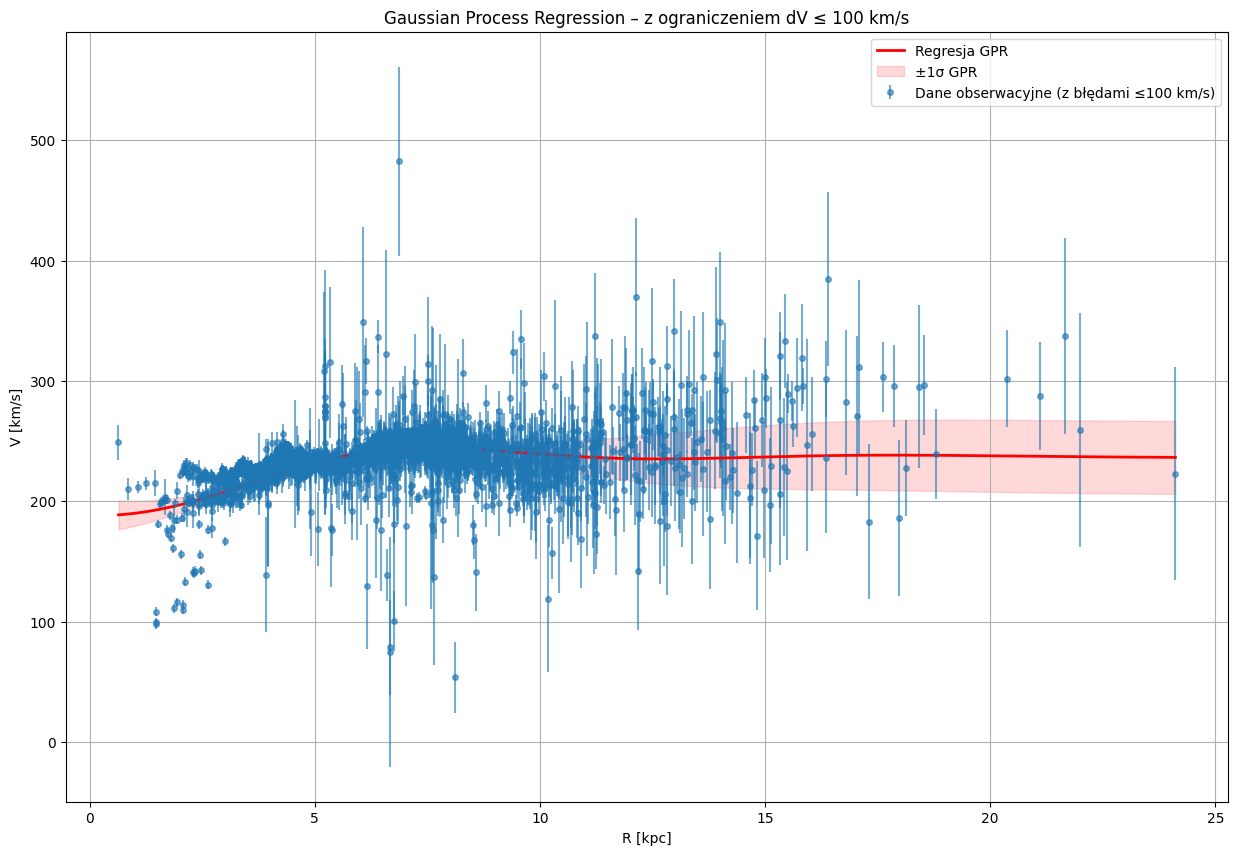

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# dane
file_path = "/content/drive/My Drive/all_montecarlo_output-kopia.dat"

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    comment="#",
    on_bad_lines="skip",
    usecols=["R", "V", "dV"]
)

# usuwamy NaNy
df = df.dropna(subset=["R", "V", "dV"])

# odfiltrowujemy niepewności > 100 km/s
df = df[df["dV"] <= 100].copy()

# ograniczamy zakres R (dla bezpieczeństwa)
df = df[(df["R"] > 0) & (df["R"] < 100)].copy()

print(f"Liczba punktów po filtracji: {len(df)}")
print(df[["R", "V", "dV"]].describe())

# przygotowanie danych
R = df["R"].values.reshape(-1, 1)
V = df["V"].values
dV = df["dV"].values

# definicja jądra (kernel)
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * RBF(length_scale=10, length_scale_bounds=(0.1, 50.0))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 10))
)

# model GPR z uwzględnieniem błędów
gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=dV**2,                 # używamy kwadratów niepewności
    n_restarts_optimizer=5,
    normalize_y=True,
    random_state=42
)
gpr.fit(R, V)

print("\n Dopasowane jądro (kernel):")
print(gpr.kernel_)

# predykcje
R_pred = np.linspace(df["R"].min(), df["R"].max(), 400).reshape(-1, 1)
V_pred, V_std = gpr.predict(R_pred, return_std=True)

# wykres
plt.figure(figsize=(15, 10))
plt.errorbar(R.ravel(), V, yerr=dV, fmt='o', color='tab:blue', ms=4, alpha=0.6,
             label='Dane obserwacyjne (z błędami ≤100 km/s)')
plt.plot(R_pred, V_pred, 'r-', lw=2, label='Regresja GPR')
plt.fill_between(R_pred.ravel(), V_pred - V_std, V_pred + V_std,
                 color='r', alpha=0.15, label='±1σ GPR')

plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Gaussian Process Regression – z ograniczeniem dV ≤ 100 km/s")
plt.legend()
plt.grid(True)
plt.show()

Jeśli znamy błędy dla poszcególnych punktów to patrzymy, czy chi2/ndf = 1 (mniej więcej)